In [49]:
import os
import time
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

from sklearn.metrics import accuracy_score, f1_score, classification_report

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [50]:
def set_seed(seed):
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

SEEDS = [42, 123, 456]

In [ ]:
imdb_train = pd.read_csv("imdb_clean_train.csv")
imdb_val   = pd.read_csv("imdb_clean_val.csv")
imdb_test  = pd.read_csv("imdb_clean_test.csv")

print(f"Train: {len(imdb_train)} | Val: {len(imdb_val)} | Test: {len(imdb_test)}")
print("Train label counts:")
print(imdb_train["label"].value_counts().sort_index())




Train: 34998 | Val: 7502 | Test: 7500
Train label counts:
label
0    17499
1    17499
Name: count, dtype: int64

Columns in train set: ['id', 'text', 'label']
      id                                               text  label
0  33064  Now, I love bad, old skifee movies as much as ...      0
1  27663  OK, I read the director's comment about this m...      0
2  44415  Greetings again from the darkness. Mary Heron ...      1
3  40454  I don't know what it is with this movies. But ...      1
4  36287  I expected so much more than what I received f...      0


In [52]:
def tokenize(text):
    return str(text).lower().split()

def build_vocab(texts, max_vocab_size=20000):
    counter = Counter()
    for text in texts:
        counter.update(tokenize(text))
    vocab = {"<PAD>": 0, "<UNK>": 1}
    for word, _ in counter.most_common(max_vocab_size - 2):
        vocab[word] = len(vocab)
    return vocab

def encode(text, vocab, max_len=128):
    tokens = tokenize(text)[:max_len]
    ids = [vocab.get(t, 1) for t in tokens]
    ids += [0] * (max_len - len(ids))
    return ids

vocab = build_vocab(imdb_train["text"], max_vocab_size=20000)
VOCAB_SIZE = len(vocab)
MAX_LEN = 128
NUM_CLASSES = 2

print(f"Vocab size: {VOCAB_SIZE}")
print(f"Number of classes: {NUM_CLASSES}")

Vocab size: 20000
Number of classes: 2


In [53]:
class TextDataset(Dataset):
    def __init__(self, df, vocab, max_len=128):
        self.labels = df["label"].tolist()
        self.encoded = [encode(t, vocab, max_len) for t in df["text"]]

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        x = torch.tensor(self.encoded[idx], dtype=torch.long)
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y

def get_loaders(train_df, val_df, test_df, vocab, max_len=128, batch_size=64):
    train_ds = TextDataset(train_df, vocab, max_len)
    val_ds   = TextDataset(val_df, vocab, max_len)
    test_ds  = TextDataset(test_df, vocab, max_len)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = get_loaders(
    imdb_train, imdb_val, imdb_test,
    vocab, max_len=MAX_LEN, batch_size=64
    )


In [ ]:
class FastText(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        x = self.embedding(x)     
        x = x.mean(dim=1)          
        x = self.dropout(x)
        x = self.fc(x)
        return x

In [55]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        out = model(x)
        loss = criterion(out, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(y)
        correct += (out.argmax(1) == y).sum().item()
        total += len(y)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            out = model(x)
            loss = criterion(out, y)

            total_loss += loss.item() * len(y)
            preds = out.argmax(1)

            correct += (preds == y).sum().item()
            total += len(y)

            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(y.cpu().tolist())

    avg_loss = total_loss / total
    acc = correct / total
    f1 = f1_score(all_labels, all_preds, average="macro")

    return avg_loss, acc, f1, all_preds, all_labels


In [ ]:
torch.set_grad_enabled(True)
def run_experiment(train_loader, val_loader, test_loader,
                   vocab_size, num_classes, seed,
                   embed_dim=64, dropout=0.3,
                   lr=0.1, epochs=5):

    set_seed(seed)

    model = FastText(vocab_size, embed_dim, num_classes, dropout).to(device)

    for name, p in model.named_parameters():
        print(name, p.requires_grad)

    optimizer = Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    scheduler = ReduceLROnPlateau(optimizer, patience=2, factor=0.5)

    best_val_acc = -1
    best_epoch = 0
    best_model_state = None
    history = []

    train_start = time.time()

    for epoch in range(1, epochs + 1):
        t0 = time.time()

        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_acc, val_f1, _, _ = evaluate(model, val_loader, criterion)

        scheduler.step(val_loss)
        elapsed = time.time() - t0

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
            "val_f1": val_f1,
            "epoch_time": elapsed
        })

        print(
            f"Epoch {epoch:02d} | "
            f"train_loss: {train_loss:.4f} | "
            f"val_loss: {val_loss:.4f} | "
            f"val_acc: {val_acc:.6f} | "
            f"val_f1: {val_f1:.6f} | "
            f"{elapsed:.1f}s"
        )

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    train_time = time.time() - train_start

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    t0 = time.time()
    _, test_acc, test_f1, test_preds, test_labels = evaluate(model, test_loader, criterion)
    inference_time = time.time() - t0

    print(
        f"\nSeed {seed} -> "
        f"Best Val Acc: {best_val_acc:.6f} | "
        f"Test Acc: {test_acc:.6f} | "
        f"Test F1: {test_f1:.6f} | "
        f"Inference: {inference_time:.2f}s"
    )

    return {
        "seed": seed,
        "model": model,
        "best_val_acc": best_val_acc,
        "best_epoch": best_epoch,
        "test_acc": test_acc,
        "test_f1": test_f1,
        "test_preds": test_preds,
        "test_labels": test_labels,
        "train_time": train_time,
        "inference_time": inference_time,
        "history": history
    }

In [57]:
print("\n" + "="*60)
print("Hyperparameter Tuning: Learning Rate")
print("="*60)

lr_candidates = [0.1, 0.5, 1.0]
lr_results = []

for lr in lr_candidates:
    print(f"\nTesting learning_rate = {lr}")

    result = run_experiment(
        train_loader, val_loader, test_loader,
        vocab_size=VOCAB_SIZE,
        num_classes=NUM_CLASSES,
        seed=42,
        lr=lr,
        epochs=5
    )

    lr_results.append({
        "learning_rate": lr,
        "best_val_acc": result["best_val_acc"],
        "best_epoch_reached": result["best_epoch"],
        "test_acc": result["test_acc"],
        "test_f1": result["test_f1"]
    })
lr_df = pd.DataFrame(lr_results)
print("\nLearning-rate tuning results:")
display(lr_df)

best_lr = lr_df.loc[lr_df["best_val_acc"].idxmax(), "learning_rate"]
print(f"\nBest learning rate (by validation accuracy): {best_lr}")


print("\n" + "="*60)
print("Hyperparameter Tuning: Epoch")
print("="*60)

epoch_candidates = [5, 10, 25]
epoch_results = []

for ep in epoch_candidates:
    print(f"\nTesting epochs = {ep}")

    result = run_experiment(
        train_loader, val_loader, test_loader,
        vocab_size=VOCAB_SIZE,
        num_classes=NUM_CLASSES,
        seed=42,
        lr=best_lr,
        epochs=ep
    )
    epoch_results.append({
        "epoch": ep,
        "best_val_acc": result["best_val_acc"],
        "best_epoch_reached": result["best_epoch"],
        "test_acc": result["test_acc"],
        "test_f1": result["test_f1"]
    })

epoch_df = pd.DataFrame(epoch_results)
print("\nEpoch tuning results:")
display(epoch_df)

best_epoch = epoch_df.loc[epoch_df["best_val_acc"].idxmax(), "epoch"]
print(f"\nBest epoch setting (by validation accuracy): {best_epoch}")




Hyperparameter Tuning: Learning Rate

Testing learning_rate = 0.1
embedding.weight True
fc.weight True
fc.bias True
Epoch 01 | train_loss: 0.4207 | val_loss: 0.3602 | val_acc: 0.842575 | val_f1: 0.842529 | 2.7s
Epoch 02 | train_loss: 0.2893 | val_loss: 0.4096 | val_acc: 0.833778 | val_f1: 0.833103 | 2.7s
Epoch 03 | train_loss: 0.2536 | val_loss: 0.4443 | val_acc: 0.834311 | val_f1: 0.834301 | 2.7s
Epoch 04 | train_loss: 0.2178 | val_loss: 0.6617 | val_acc: 0.831911 | val_f1: 0.831814 | 2.6s
Epoch 05 | train_loss: 0.1319 | val_loss: 0.6309 | val_acc: 0.832445 | val_f1: 0.832442 | 2.6s

Seed 42 -> Best Val Acc: 0.842575 | Test Acc: 0.846667 | Test F1: 0.846530 | Inference: 0.17s

Testing learning_rate = 0.5
embedding.weight True
fc.weight True
fc.bias True
Epoch 01 | train_loss: 1.4711 | val_loss: 2.0689 | val_acc: 0.723540 | val_f1: 0.718938 | 2.8s
Epoch 02 | train_loss: 2.4057 | val_loss: 3.0553 | val_acc: 0.777793 | val_f1: 0.773846 | 2.6s
Epoch 03 | train_loss: 2.5922 | val_loss: 2.

,learning_rate,best_val_acc,best_epoch_reached,test_acc,test_f1
0,0.1,0.842575,1,0.846667,0.846530
1,0.5,0.828712,5,0.828267,0.828253
2,1.0,0.826313,4,0.826800,0.826798



Best learning rate (by validation accuracy): 0.1

Hyperparameter Tuning: Epoch

Testing epochs = 5
embedding.weight True
fc.weight True
fc.bias True
Epoch 01 | train_loss: 0.4207 | val_loss: 0.3602 | val_acc: 0.842575 | val_f1: 0.842529 | 2.7s
Epoch 02 | train_loss: 0.2893 | val_loss: 0.4096 | val_acc: 0.833778 | val_f1: 0.833103 | 2.7s
Epoch 03 | train_loss: 0.2536 | val_loss: 0.4443 | val_acc: 0.834311 | val_f1: 0.834301 | 2.7s
Epoch 04 | train_loss: 0.2178 | val_loss: 0.6617 | val_acc: 0.831911 | val_f1: 0.831814 | 3.0s
Epoch 05 | train_loss: 0.1319 | val_loss: 0.6309 | val_acc: 0.832445 | val_f1: 0.832442 | 2.6s

Seed 42 -> Best Val Acc: 0.842575 | Test Acc: 0.846667 | Test F1: 0.846530 | Inference: 0.15s

Testing epochs = 10
embedding.weight True
fc.weight True
fc.bias True
Epoch 01 | train_loss: 0.4207 | val_loss: 0.3602 | val_acc: 0.842575 | val_f1: 0.842529 | 2.6s
Epoch 02 | train_loss: 0.2893 | val_loss: 0.4096 | val_acc: 0.833778 | val_f1: 0.833103 | 2.4s
Epoch 03 | train_lo

,epoch,best_val_acc,best_epoch_reached,test_acc,test_f1
0,5,0.842575,1,0.846667,0.84653
1,10,0.842575,1,0.846667,0.84653
2,25,0.842575,1,0.846667,0.84653



Best epoch setting (by validation accuracy): 5


In [58]:
results_imdb = []

for seed in SEEDS:
    result = run_experiment(
        train_loader, val_loader, test_loader,
        vocab_size=VOCAB_SIZE,
        num_classes=NUM_CLASSES,
        seed=seed,
        lr=best_lr,
        epochs=best_epoch
    )
    results_imdb.append(result)

embedding.weight True
fc.weight True
fc.bias True
Epoch 01 | train_loss: 0.4207 | val_loss: 0.3602 | val_acc: 0.842575 | val_f1: 0.842529 | 2.7s
Epoch 02 | train_loss: 0.2893 | val_loss: 0.4096 | val_acc: 0.833778 | val_f1: 0.833103 | 3.2s
Epoch 03 | train_loss: 0.2536 | val_loss: 0.4443 | val_acc: 0.834311 | val_f1: 0.834301 | 2.8s
Epoch 04 | train_loss: 0.2178 | val_loss: 0.6617 | val_acc: 0.831911 | val_f1: 0.831814 | 2.9s
Epoch 05 | train_loss: 0.1319 | val_loss: 0.6309 | val_acc: 0.832445 | val_f1: 0.832442 | 2.7s

Seed 42 -> Best Val Acc: 0.842575 | Test Acc: 0.846667 | Test F1: 0.846530 | Inference: 0.16s
embedding.weight True
fc.weight True
fc.bias True
Epoch 01 | train_loss: 0.4232 | val_loss: 0.3661 | val_acc: 0.841242 | val_f1: 0.841239 | 2.8s
Epoch 02 | train_loss: 0.2919 | val_loss: 0.4181 | val_acc: 0.835777 | val_f1: 0.835451 | 2.6s
Epoch 03 | train_loss: 0.2518 | val_loss: 0.4791 | val_acc: 0.826180 | val_f1: 0.825871 | 3.1s
Epoch 04 | train_loss: 0.2250 | val_loss: 0.5

Raw results:


,seed,best_val_acc,best_epoch,test_acc,test_f1,train_time,inference_time
0,42,0.842575,1,0.846667,0.846530,14.257455,0.160195
1,123,0.841242,1,0.837200,0.837164,14.166370,0.198476
2,456,0.835244,2,0.830667,0.829976,13.741680,0.148609



Summary statistics:


,metric,mean,std
0,best_val_acc,0.839687,0.003905
1,test_acc,0.838178,0.008045
2,test_f1,0.837890,0.008301
3,train_time,14.055168,0.275282
4,inference_time,0.169093,0.026097


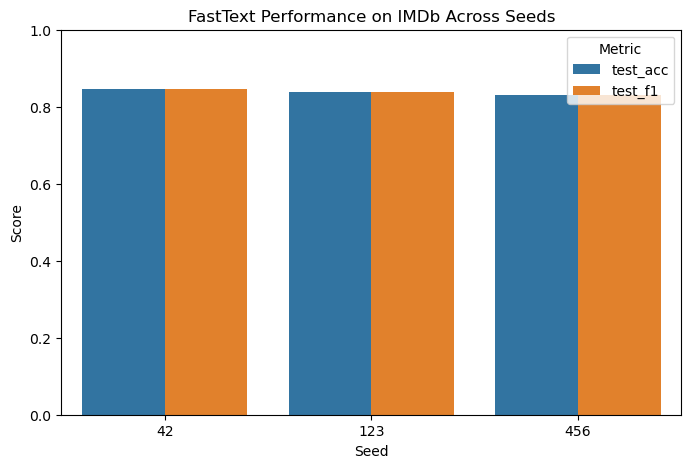

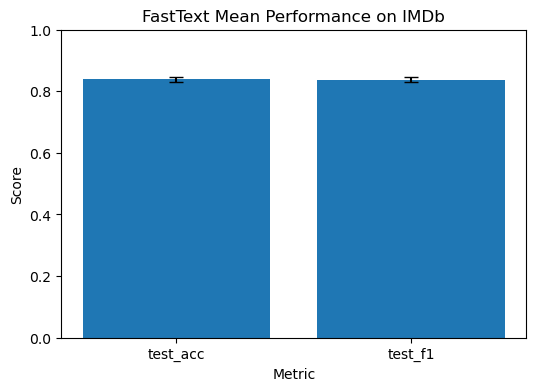


Report-ready summary:
FastText achieved a mean test accuracy of 0.8382 ± 0.0080, and a mean macro-F1 of 0.8379 ± 0.0083 across 3 random seeds.
Average training time: 14.06s ± 0.28s
Average inference time: 0.17s ± 0.03s


In [ ]:
results_df = pd.DataFrame([
    {
        "seed": r["seed"],
        "best_val_acc": r["best_val_acc"],
        "best_epoch": r["best_epoch"],
        "test_acc": r["test_acc"],
        "test_f1": r["test_f1"],
        "train_time": r["train_time"],
        "inference_time": r["inference_time"]
    }
    for r in results_imdb
])

print("Raw results:")
display(results_df)
results_df.to_csv("imdb_results.csv", index=False)
summary_df = pd.DataFrame({
    "metric": ["best_val_acc", "test_acc", "test_f1", "train_time", "inference_time"],
    "mean": [
        results_df["best_val_acc"].mean(),
        results_df["test_acc"].mean(),
        results_df["test_f1"].mean(),
        results_df["train_time"].mean(),
        results_df["inference_time"].mean()
    ],
    "std": [
        results_df["best_val_acc"].std(),
        results_df["test_acc"].std(),
        results_df["test_f1"].std(),
        results_df["train_time"].std(),
        results_df["inference_time"].std()
    ]
})
print("\nSummary statistics:")
display(summary_df)
summary_df.to_csv("imdb_summary.csv", index=False)


# Plot 1
plot_df = results_df.melt(
    id_vars="seed",
    value_vars=["test_acc", "test_f1"],
    var_name="metric",
    value_name="score"
)

plt.figure(figsize=(8, 5))
sns.barplot(data=plot_df, x="seed", y="score", hue="metric")
plt.title("FastText Performance on IMDb Across Seeds")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xlabel("Seed")
plt.legend(title="Metric")
plt.savefig("imdb_barplot.png", dpi=300, bbox_inches="tight")
plt.show()

# Plot 2
perf_summary = summary_df[summary_df["metric"].isin(["test_acc", "test_f1"])]

plt.figure(figsize=(6, 4))
plt.bar(
    perf_summary["metric"],
    perf_summary["mean"],
    yerr=perf_summary["std"],
    capsize=5
)
plt.title("FastText Mean Performance on IMDb")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xlabel("Metric")
plt.savefig("imdb_mean_performance.png", dpi=300, bbox_inches="tight")
plt.show()


print("\nReport-ready summary:")
print(
    f"FastText achieved a mean test accuracy of "
    f"{results_df['test_acc'].mean():.4f} ± {results_df['test_acc'].std():.4f}, "
    f"and a mean macro-F1 of "
    f"{results_df['test_f1'].mean():.4f} ± {results_df['test_f1'].std():.4f} "
    f"across {len(results_df)} random seeds."
    )

print(
    f"Average training time: "
    f"{results_df['train_time'].mean():.2f}s ± {results_df['train_time'].std():.2f}s"
)

print(
    f"Average inference time: "
    f"{results_df['inference_time'].mean():.2f}s ± {results_df['inference_time'].std():.2f}s"
)

In [ ]:
# Data Efficiency Experiment

fractions = [1.0, 0.5, 0.25, 0.10, 0.05, 0.01]
efficiency_results = []

def stratified_subset(df, frac, seed=42):
    parts = []
    for _, group in df.groupby("label"):
        n = max(1, int(round(len(group) * frac)))
        sampled = group.sample(n=n, random_state=seed)
        parts.append(sampled)
    subset = pd.concat(parts, axis=0).sample(frac=1, random_state=seed).reset_index(drop=True)
    return subset

print("\n" + "="*70)
print("DATA EFFICIENCY EXPERIMENT - IMDb")
print("="*70)

for frac in fractions:

    print(f"\n{'='*60}")
    print(f"Running FastText on {int(frac * 100)}% of training data")
    print(f"{'='*60}")

    train_subset = stratified_subset(imdb_train, frac, seed=42)

    print(f"Train size: {len(train_subset)}")
    print(train_subset["label"].value_counts().sort_index())

    train_loader_eff, val_loader_eff, test_loader_eff = get_loaders(
        train_subset,
        imdb_val,
        imdb_test,
        vocab,
        max_len=MAX_LEN,
        batch_size=64
    )

    for seed in SEEDS:

        print(f"\n--- Fraction {frac}, Seed {seed} ---")

        result = run_experiment(
            train_loader_eff,
            val_loader_eff,
            test_loader_eff,
            vocab_size=VOCAB_SIZE,
            num_classes=NUM_CLASSES,
            seed=seed,
            lr=best_lr,
            epochs=best_epoch
        )

       
        efficiency_results.append({
            "fraction": frac,
            "train_size": len(train_subset),
            "seed": result["seed"],
            "best_val_acc": result["best_val_acc"],
            "test_acc": result["test_acc"],
            "test_f1": result["test_f1"],
            "train_time": result["train_time"],
            "inference_time": result["inference_time"]
        })



efficiency_df = pd.DataFrame(efficiency_results)

print("\nFull Data Efficiency Results:")
display(efficiency_df)

efficiency_df.to_csv("imdb_data_efficiency_full.csv", index=False)


DATA EFFICIENCY EXPERIMENT - IMDb

Running FastText on 100% of training data
Train size: 34998
label
0    17499
1    17499
Name: count, dtype: int64

--- Fraction 1.0, Seed 42 ---
embedding.weight True
fc.weight True
fc.bias True
Epoch 01 | train_loss: 0.4236 | val_loss: 0.3616 | val_acc: 0.844441 | val_f1: 0.844439 | 2.8s
Epoch 02 | train_loss: 0.2913 | val_loss: 0.4422 | val_acc: 0.827246 | val_f1: 0.826588 | 2.9s
Epoch 03 | train_loss: 0.2469 | val_loss: 0.5272 | val_acc: 0.824314 | val_f1: 0.822901 | 2.8s
Epoch 04 | train_loss: 0.2189 | val_loss: 0.5181 | val_acc: 0.827246 | val_f1: 0.827002 | 3.0s
Epoch 05 | train_loss: 0.1343 | val_loss: 0.6353 | val_acc: 0.826446 | val_f1: 0.826438 | 2.8s

Seed 42 -> Best Val Acc: 0.844441 | Test Acc: 0.843067 | Test F1: 0.843023 | Inference: 0.15s

--- Fraction 1.0, Seed 123 ---
embedding.weight True
fc.weight True
fc.bias True
Epoch 01 | train_loss: 0.4227 | val_loss: 0.3819 | val_acc: 0.842842 | val_f1: 0.842682 | 2.7s
Epoch 02 | train_loss:

,fraction,train_size,seed,best_val_acc,test_acc,test_f1,train_time,inference_time
0,1.00,34998,42,0.844441,0.843067,0.843023,14.364198,0.147179
1,1.00,34998,123,0.842842,0.839333,0.839046,14.163766,0.162063
2,1.00,34998,456,0.830845,0.825867,0.825553,14.379982,0.152647
3,0.50,17500,42,0.834044,0.832533,0.832468,7.712390,0.177488
4,0.50,17500,123,0.836710,0.842000,0.841997,7.448123,0.170466
5,0.50,17500,456,0.826979,0.825867,0.825162,7.746971,0.163225
6,0.25,8750,42,0.815116,0.820667,0.820183,4.376904,0.178979
7,0.25,8750,123,0.814583,0.820133,0.819261,4.119363,0.166887
8,0.25,8750,456,0.817649,0.823733,0.823353,4.146726,0.157671
9,0.10,3500,42,0.774060,0.780667,0.780555,2.226600,0.163243



Summary Data Efficiency Results:


,fraction,train_size,mean_test_acc,std_test_acc,mean_test_f1,std_test_f1,mean_train_time,std_train_time,mean_inference_time,std_inference_time
0,1.00,34998,0.836089,0.009047,0.835874,0.009157,14.302649,0.120534,0.153963,0.007529
1,0.50,17500,0.833467,0.008107,0.833209,0.008441,7.635828,0.163474,0.170393,0.007132
2,0.25,8750,0.821511,0.001943,0.820932,0.002146,4.214331,0.141455,0.167846,0.010686
3,0.10,3500,0.782844,0.002798,0.782785,0.002804,2.180090,0.070653,0.180197,0.022293
4,0.05,1750,0.772000,0.001937,0.771466,0.002187,1.582142,0.038147,0.162393,0.007767
5,0.01,350,0.697422,0.004411,0.695088,0.004264,1.027401,0.017492,0.177268,0.006062


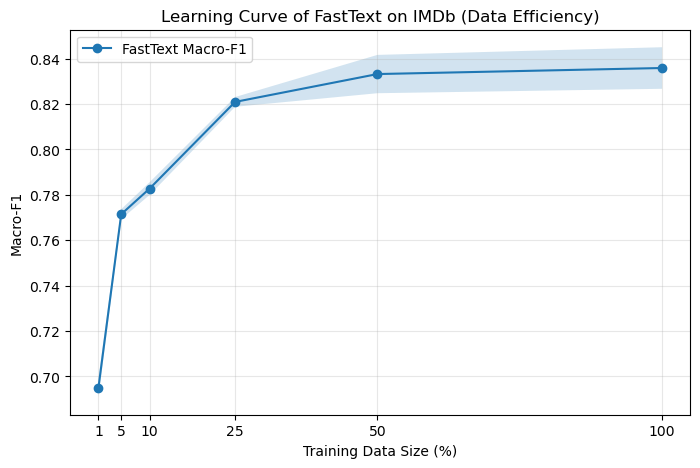

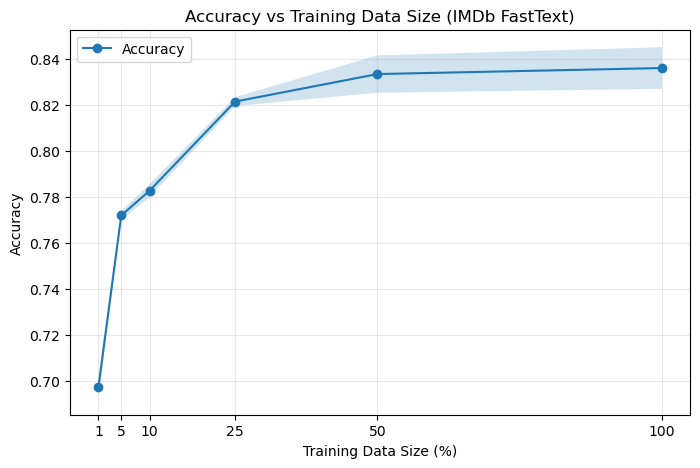

In [ ]:
efficiency_summary = (
    efficiency_df
    .groupby("fraction", as_index=False)
    .agg({
        "train_size": "first",
        "test_acc": ["mean", "std"],
        "test_f1": ["mean", "std"],
        "train_time": ["mean", "std"],
        "inference_time": ["mean", "std"]
    })
)

efficiency_summary.columns = [
    "fraction",
    "train_size",
    "mean_test_acc",
    "std_test_acc",
    "mean_test_f1",
    "std_test_f1",
    "mean_train_time",
    "std_train_time",
    "mean_inference_time",
    "std_inference_time"
]

efficiency_summary = efficiency_summary.sort_values("fraction", ascending=False).reset_index(drop=True)

print("\nSummary Data Efficiency Results:")
display(efficiency_summary)

efficiency_summary.to_csv("imdb_data_efficiency_summary.csv", index=False)



# Learning Curves
plot_df = efficiency_summary.sort_values("fraction")
x = plot_df["fraction"] * 100

# F1 Curve
plt.figure(figsize=(8, 5))
plt.plot(x, plot_df["mean_test_f1"], marker="o", label="FastText Macro-F1")
plt.fill_between(
    x,
    plot_df["mean_test_f1"] - plot_df["std_test_f1"],
    plot_df["mean_test_f1"] + plot_df["std_test_f1"],
    alpha=0.2
)
plt.title("Learning Curve of FastText on IMDb (Data Efficiency)")
plt.xlabel("Training Data Size (%)")
plt.ylabel("Macro-F1")
plt.xticks(x)
plt.grid(True, alpha=0.3)
plt.legend()
plt.savefig("imdb_learning_curve_f1.png", dpi=300, bbox_inches="tight")
plt.show()

# Accuracy Curve
plt.figure(figsize=(8, 5))
plt.plot(x, plot_df["mean_test_acc"], marker="o", label="Accuracy")
plt.fill_between(
    x,
    plot_df["mean_test_acc"] - plot_df["std_test_acc"],
    plot_df["mean_test_acc"] + plot_df["std_test_acc"],
    alpha=0.2
)
plt.title("Accuracy vs Training Data Size (IMDb FastText)")
plt.xlabel("Training Data Size (%)")
plt.ylabel("Accuracy")
plt.xticks(x)
plt.grid(True, alpha=0.3)
plt.legend()
plt.savefig("imdb_learning_curve_acc.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
def get_misclassified_examples(texts, true_labels, pred_labels):
    df = pd.DataFrame({
        "text": texts,
        "true": true_labels,
        "pred": pred_labels
    })
    df["correct"] = df["true"] == df["pred"]
    return df[df["correct"] == False].reset_index(drop=True)

fasttext_best_run = max(results_imdb, key=lambda x: x["test_acc"])

print("Selected FastText seed for error analysis:", fasttext_best_run["seed"])
print("FastText test_acc:", fasttext_best_run["test_acc"])
print("FastText test_f1:", fasttext_best_run["test_f1"])

fasttext_errors = get_misclassified_examples(
    imdb_test["text"].tolist(),
    fasttext_best_run["test_labels"],
    fasttext_best_run["test_preds"]
)

print("Total misclassified examples:", len(fasttext_errors))

fasttext_error_sample = fasttext_errors.sample(
    n=min(25, len(fasttext_errors)),
    random_state=42
).reset_index(drop=True)

fasttext_error_sample["word_count"] = fasttext_error_sample["text"].apply(lambda x: len(str(x).split()))
fasttext_error_sample["very_short_text"] = fasttext_error_sample["word_count"] <= 5
fasttext_error_sample["failure_mode"] = ""
fasttext_error_sample["notes"] = ""

print("\n===== 25 Misclassified Examples from FastText =====")
display(
    fasttext_error_sample[
        ["text", "true", "pred", "word_count", "very_short_text", "failure_mode", "notes"]
    ]
)

fasttext_error_sample[
    ["text", "true", "pred", "word_count", "very_short_text", "failure_mode", "notes"]
].to_csv(
    "imdb_fasttext_25_misclassified_with_failure_modes.csv",
    index=False
)

print("\nSaved: imdb_fasttext_25_misclassified_with_failure_modes.csv")

Selected FastText seed for error analysis: 42
FastText test_acc: 0.8466666666666667
FastText test_f1: 0.8465297684918017
Total misclassified examples: 1150

===== 25 Misclassified Examples from FastText =====


,text,true,pred,word_count,very_short_text,failure_mode,notes
0,"Demer Daves,is a wonderful director when it co...",0,1,128,False,,
1,This movie has to be my favorite of all time. ...,1,0,128,False,,
2,If you are under 13 or above 13 and pretty int...,1,0,128,False,,
3,"The Cell is weak on plot, filled with holes an...",1,0,128,False,,
4,I have to hold Barney drilling my head every d...,1,0,128,False,,
5,I've heard a lot about Porno Holocaust and its...,1,0,128,False,,
6,"Really, I liked it. The premise was good, the ...",1,0,100,False,,
7,Um .... a serious film about troubled teens in...,1,0,128,False,,
8,This sickly sweet and laboriously paced 5-reel...,0,1,64,False,,
9,I usually check out the MTV movie awards to wa...,0,1,128,False,,



Saved: imdb_fasttext_25_misclassified_with_failure_modes.csv
